In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,6)

c:\Users\LENOVO\OneDrive\Desktop\AI_Stock_Market_Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SUPPORTED_STOCKS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA"
]

In [3]:
def prophet_forecasting(ticker):

    print("\n" + "="*70)
    print(f"PROPHET FORECASTING : {ticker}")
    print("="*70)

    DATA_PATH = f"../data/{ticker}/processed/processed_stock_data.csv"

    MODEL_DIR = f"../models/{ticker}"
    REPORT_DIR = f"../reports/{ticker}"

    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(REPORT_DIR, exist_ok=True)

    stock = pd.read_csv(DATA_PATH)

    stock["Date"] = pd.to_datetime(stock["Date"])

    prophet_data = stock[["Date", "Close"]].copy()

    prophet_data.columns = ["ds", "y"]

    prophet_data = prophet_data.sort_values("ds").reset_index(drop=True)

    print("Dataset Loaded Successfully")
    print(prophet_data.head())

    return prophet_data, MODEL_DIR, REPORT_DIR

In [4]:
def train_test_split_prophet(prophet_data):

    train_size = int(len(prophet_data) * 0.80)

    train = prophet_data.iloc[:train_size].copy()
    test = prophet_data.iloc[train_size:].copy()

    print("\nTraining Samples :", len(train))
    print("Testing Samples  :", len(test))

    return train, test

In [5]:
def build_prophet():

    model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )

    return model

In [6]:
def train_prophet_model(train, ticker):

    print("\nTraining Prophet Model...")

    model = build_prophet()

    model.fit(train)

    print("Model Trained Successfully!")

    return model

In [7]:
def generate_forecast(model, prophet_data):

    future = model.make_future_dataframe(
        periods=30,
        freq="B"
    )

    forecast = model.predict(future)

    print("\nForecast Generated Successfully!")

    return forecast

In [8]:
def evaluate_model(model, train, test):

    future_test = test[["ds"]].copy()

    prediction = model.predict(future_test)

    actual = test["y"].values
    predicted = prediction["yhat"].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print("\nModel Performance")
    print("-"*40)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return prediction

In [9]:
def plot_forecast(model, forecast, ticker):

    fig = model.plot(forecast)

    plt.title(f"{ticker} Prophet Forecast")

    plt.xlabel("Date")
    plt.ylabel("Closing Price")

    plt.grid(True)

    plt.show()

In [10]:
def plot_components(model, forecast):

    model.plot_components(forecast)

    plt.show()

In [11]:
def save_results(model,
                 forecast,
                 MODEL_DIR,
                 REPORT_DIR,
                 ticker):

    model_path = os.path.join(
        MODEL_DIR,
        "prophet_model.pkl"
    )

    forecast_path = os.path.join(
        REPORT_DIR,
        "prophet_forecast.csv"
    )

    joblib.dump(model, model_path)

    forecast.to_csv(
        forecast_path,
        index=False
    )

    print("\nFiles Saved Successfully!")

    print("Model    :", model_path)
    print("Forecast :", forecast_path)


PROPHET FORECASTING : AAPL
Dataset Loaded Successfully
          ds           y
0 2023-03-15  152.990005
1 2023-03-16  155.850006
2 2023-03-17  155.000000
3 2023-03-20  157.399994
4 2023-03-21  159.279999

Training Samples : 676
Testing Samples  : 169

Training Prophet Model...


20:08:07 - cmdstanpy - INFO - Chain [1] start processing
20:08:12 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Forecast Generated Successfully!

Model Performance
----------------------------------------
MAE  : 31.0123
RMSE : 35.7490
R²   : -1.5168


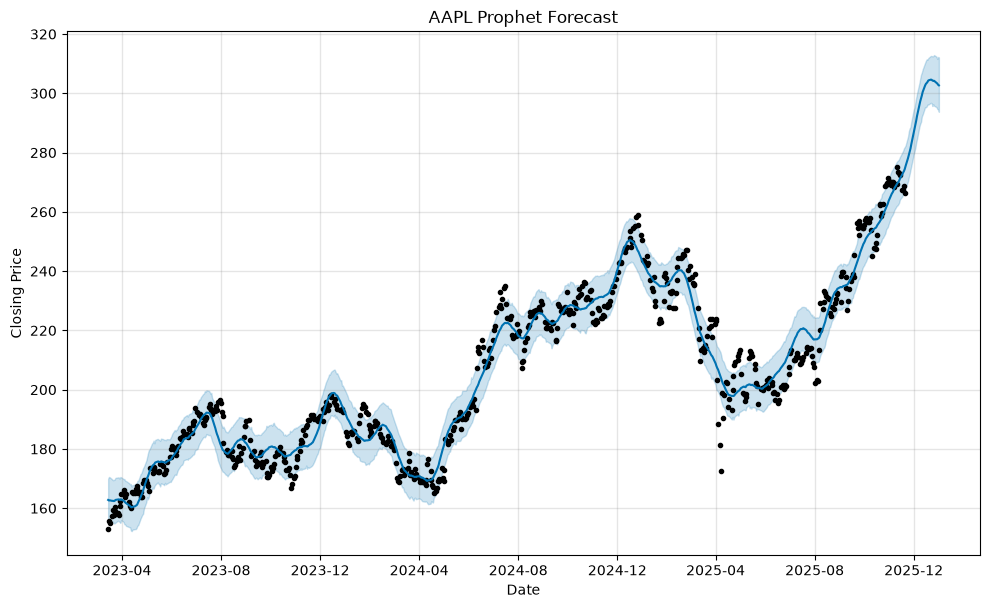

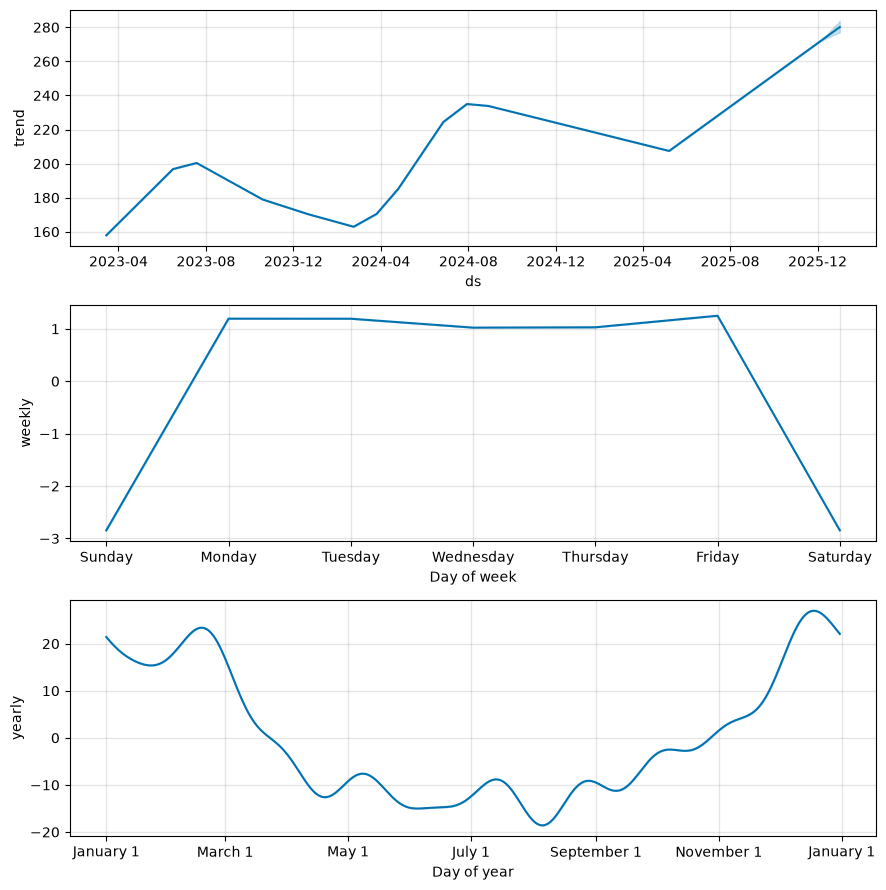


Files Saved Successfully!
Model    : ../models/AAPL\prophet_model.pkl
Forecast : ../reports/AAPL\prophet_forecast.csv

PROPHET FORECASTING : MSFT
Dataset Loaded Successfully
          ds           y
0 2023-03-15  265.440002
1 2023-03-16  276.200012
2 2023-03-17  279.429993
3 2023-03-20  272.230011
4 2023-03-21  273.779999

Training Samples : 676
Testing Samples  : 169

Training Prophet Model...


20:08:23 - cmdstanpy - INFO - Chain [1] start processing
20:08:25 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Forecast Generated Successfully!

Model Performance
----------------------------------------
MAE  : 145.8593
RMSE : 163.2880
R²   : -16.6976


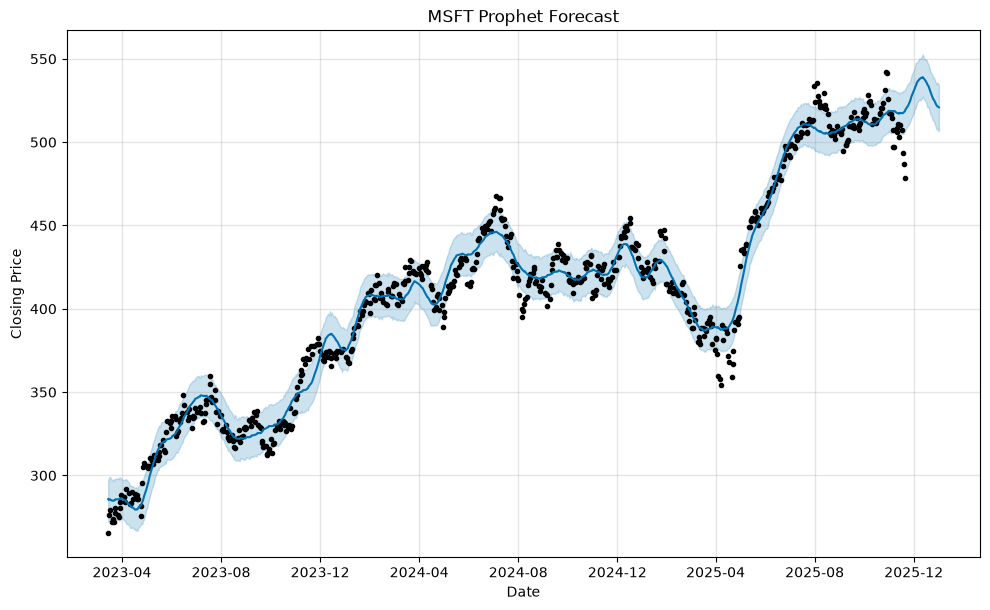

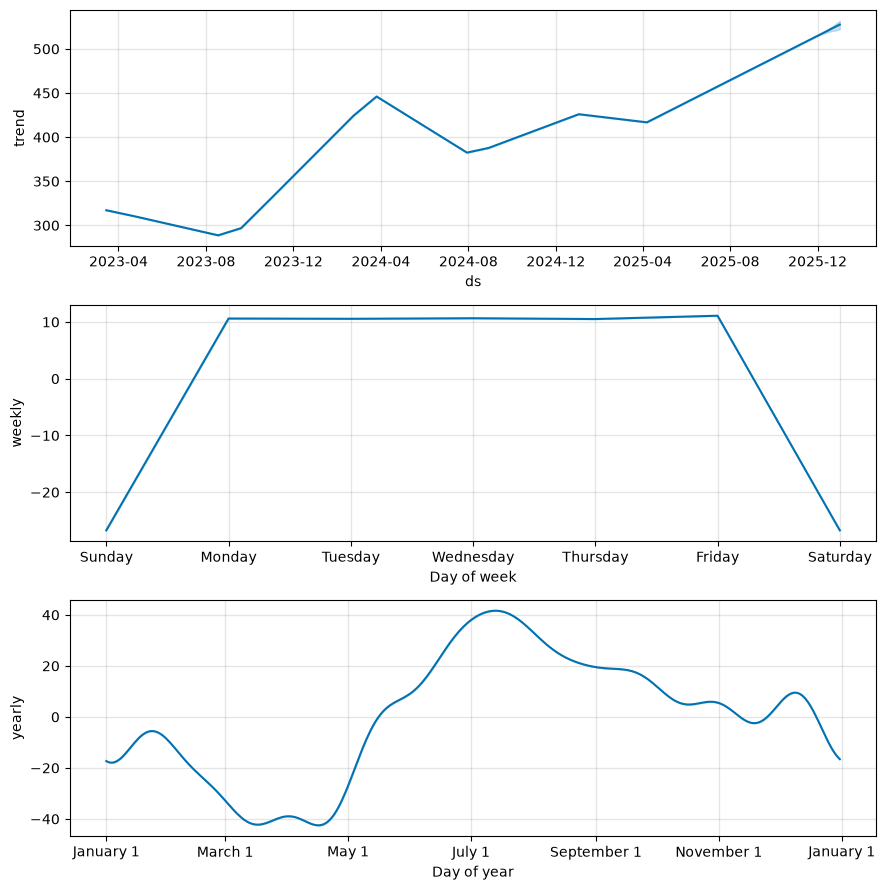


Files Saved Successfully!
Model    : ../models/MSFT\prophet_model.pkl
Forecast : ../reports/MSFT\prophet_forecast.csv

PROPHET FORECASTING : GOOGL
Dataset Loaded Successfully
          ds           y
0 2023-03-15   96.110001
1 2023-03-16  100.320000
2 2023-03-17  101.620003
3 2023-03-20  101.220001
4 2023-03-21  104.919998

Training Samples : 676
Testing Samples  : 169

Training Prophet Model...


20:08:34 - cmdstanpy - INFO - Chain [1] start processing
20:08:34 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Forecast Generated Successfully!

Model Performance
----------------------------------------
MAE  : 37.1559
RMSE : 44.1418
R²   : -1.1470


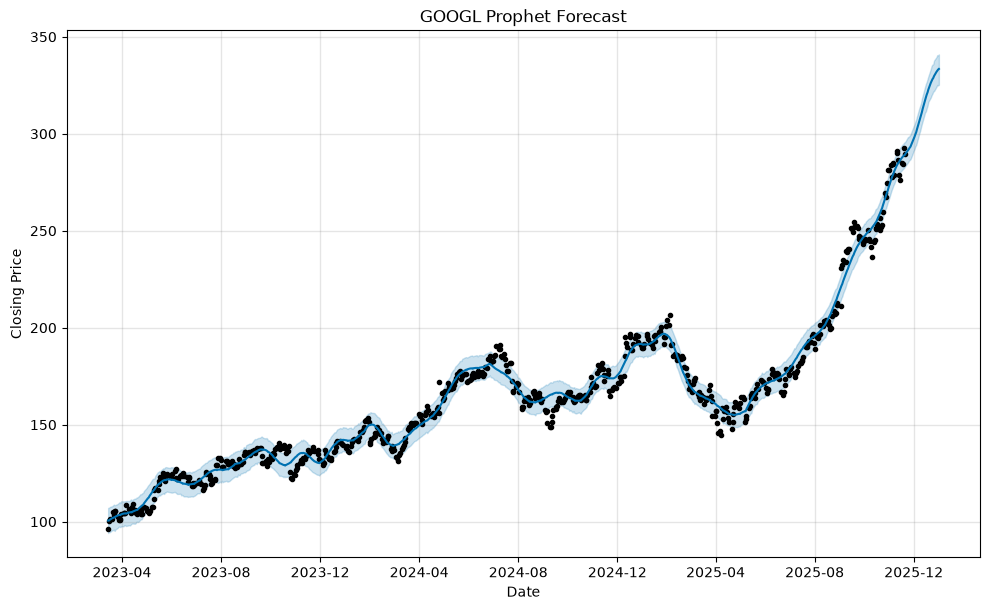

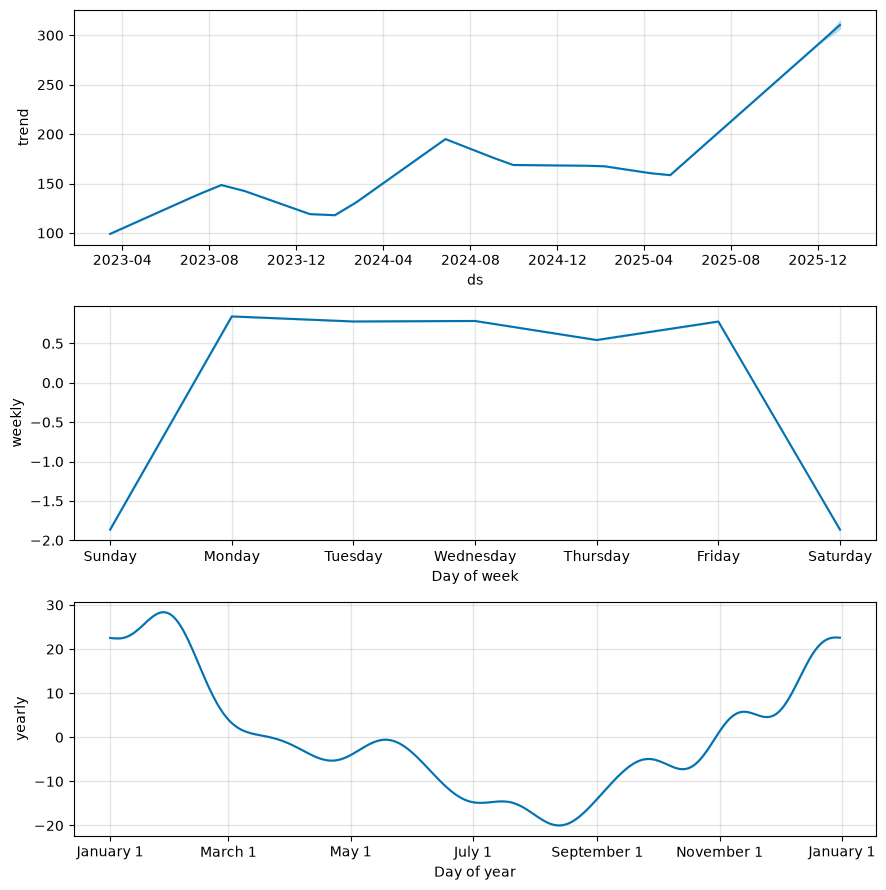


Files Saved Successfully!
Model    : ../models/GOOGL\prophet_model.pkl
Forecast : ../reports/GOOGL\prophet_forecast.csv

PROPHET FORECASTING : AMZN
Dataset Loaded Successfully
          ds           y
0 2023-03-15   96.199997
1 2023-03-16  100.040001
2 2023-03-17   98.949997
3 2023-03-20   97.709999
4 2023-03-21  100.610001

Training Samples : 676
Testing Samples  : 169

Training Prophet Model...


20:08:39 - cmdstanpy - INFO - Chain [1] start processing
20:08:40 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Forecast Generated Successfully!

Model Performance
----------------------------------------
MAE  : 28.6607
RMSE : 34.4606
R²   : -2.0612


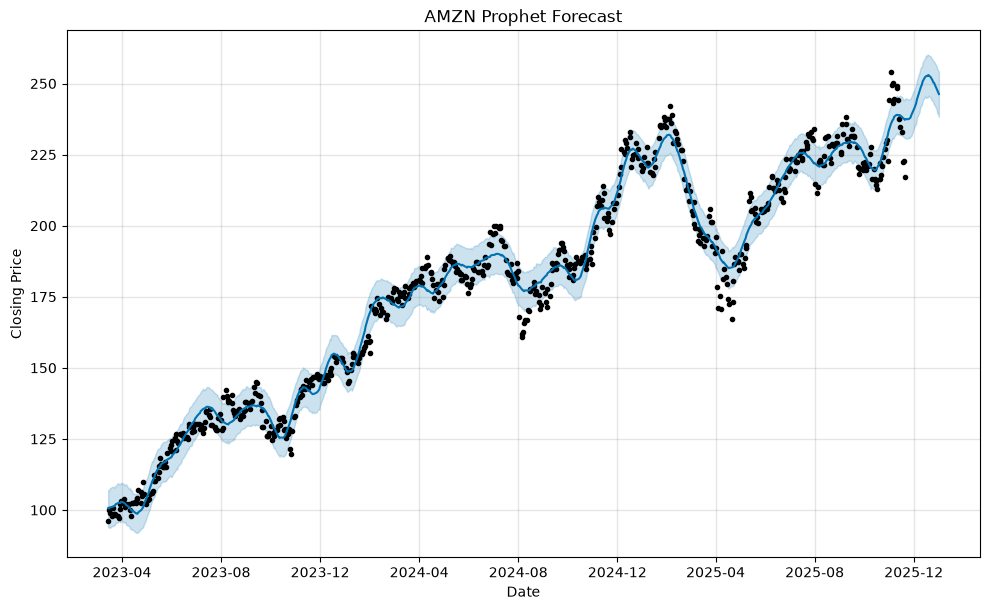

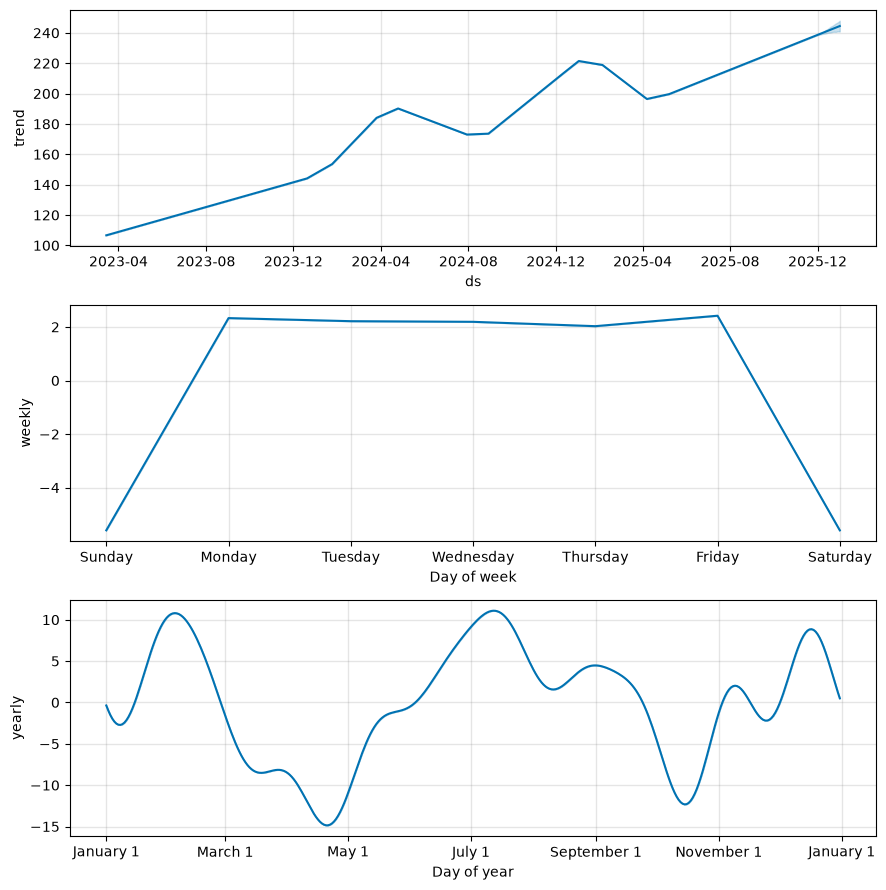


Files Saved Successfully!
Model    : ../models/AMZN\prophet_model.pkl
Forecast : ../reports/AMZN\prophet_forecast.csv

PROPHET FORECASTING : NVDA
Dataset Loaded Successfully
          ds          y
0 2023-03-15  24.228001
1 2023-03-16  25.541000
2 2023-03-17  25.725000
3 2023-03-20  25.900000
4 2023-03-21  26.198999

Training Samples : 676
Testing Samples  : 169

Training Prophet Model...


20:08:47 - cmdstanpy - INFO - Chain [1] start processing
20:08:47 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Forecast Generated Successfully!

Model Performance
----------------------------------------
MAE  : 37.1992
RMSE : 42.5308
R²   : -7.6620


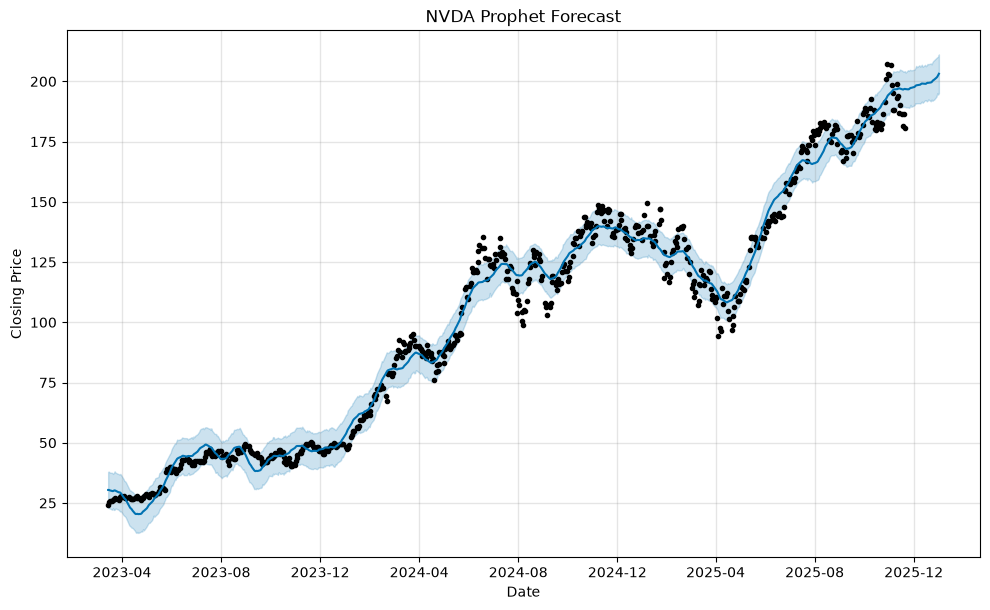

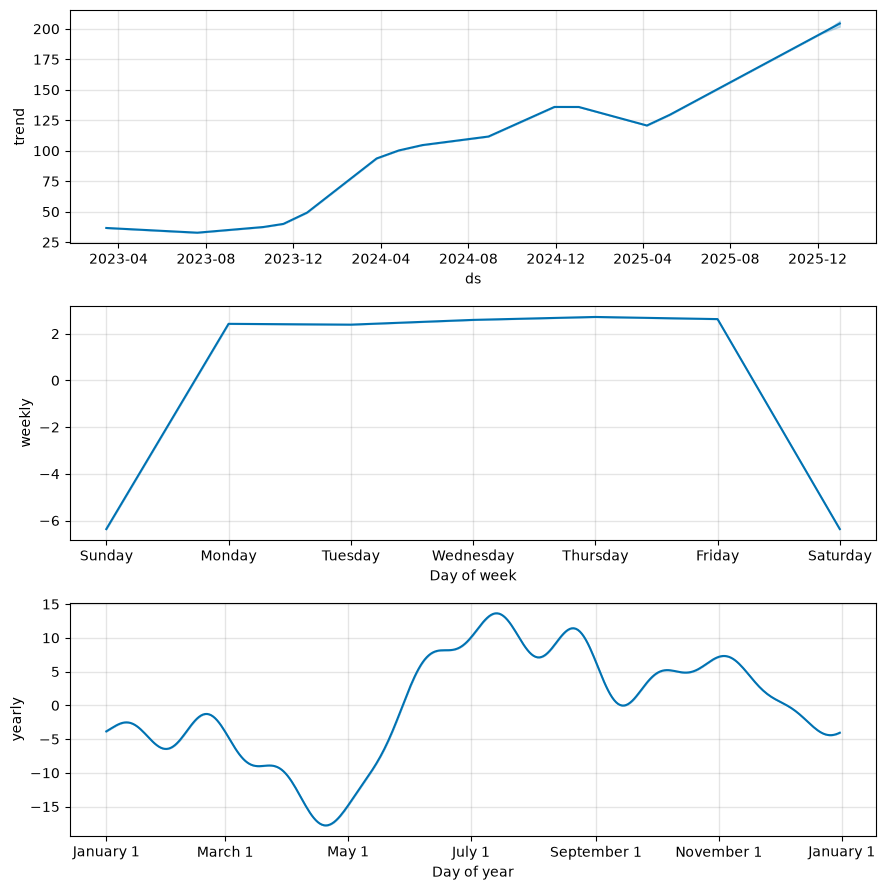


Files Saved Successfully!
Model    : ../models/NVDA\prophet_model.pkl
Forecast : ../reports/NVDA\prophet_forecast.csv

LAB 6 COMPLETED SUCCESSFULLY


In [12]:
for ticker in SUPPORTED_STOCKS:

    prophet_data, MODEL_DIR, REPORT_DIR = prophet_forecasting(ticker)

    train, test = train_test_split_prophet(prophet_data)

    model = train_prophet_model(train, ticker)

    forecast = generate_forecast(model, prophet_data)

    prediction = evaluate_model(
        model,
        train,
        test
    )

    plot_forecast(
        model,
        forecast,
        ticker
    )

    plot_components(
        model,
        forecast
    )

    save_results(
        model,
        forecast,
        MODEL_DIR,
        REPORT_DIR,
        ticker
    )

print("\n" + "="*70)
print("LAB 6 COMPLETED SUCCESSFULLY")
print("="*70)